In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv('Sleep_disorder_data.csv')

# Inspect basic structure
print("Dataset Shape:", df.shape)
print("\n--- Column Data Types & Non-Null Counts ---")
df.info()

print("\n--- Missing Value Count ---")
print(df.isnull().sum())

Dataset Shape: (374, 13)

--- Column Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64

In [4]:
# 1. Handle missing values: Fill NaN in Sleep Disorder with 'None'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# 2. Standardize categories: Merge 'Normal Weight' into 'Normal'
df['BMI Category'] = df['BMI Category'].replace({'Normal Weight': 'Normal'})

# 3. Feature engineering: Split 'Blood Pressure' into Systolic and Diastolic integers
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

# 4. Drop non-informative features
df_clean = df.drop(columns=['Person ID', 'Blood Pressure'])

print("Data Cleaning Complete. Sample Rows:")
df_clean.head()

Data Cleaning Complete. Sample Rows:


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [5]:
# Numerical attributes summary
print("--- Numerical Feature Statistics ---")
display(df_clean.describe())

# Categorical attributes breakdown
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']
print("\n--- Categorical Value Distributions ---")
for col in categorical_cols:
    print(f"\nValue Counts for {col}:")
    print(df_clean[col].value_counts())

--- Numerical Feature Statistics ---


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920,128.553476,84.649733
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679,7.748118,6.161611
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000,115.000000,75.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000,125.000000,80.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000,130.000000,85.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000,135.000000,90.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000,142.000000,95.000000



--- Categorical Value Distributions ---

Value Counts for Gender:
Gender
Male      189
Female    185
Name: count, dtype: int64

Value Counts for Occupation:
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

Value Counts for BMI Category:
BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64

Value Counts for Sleep Disorder:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


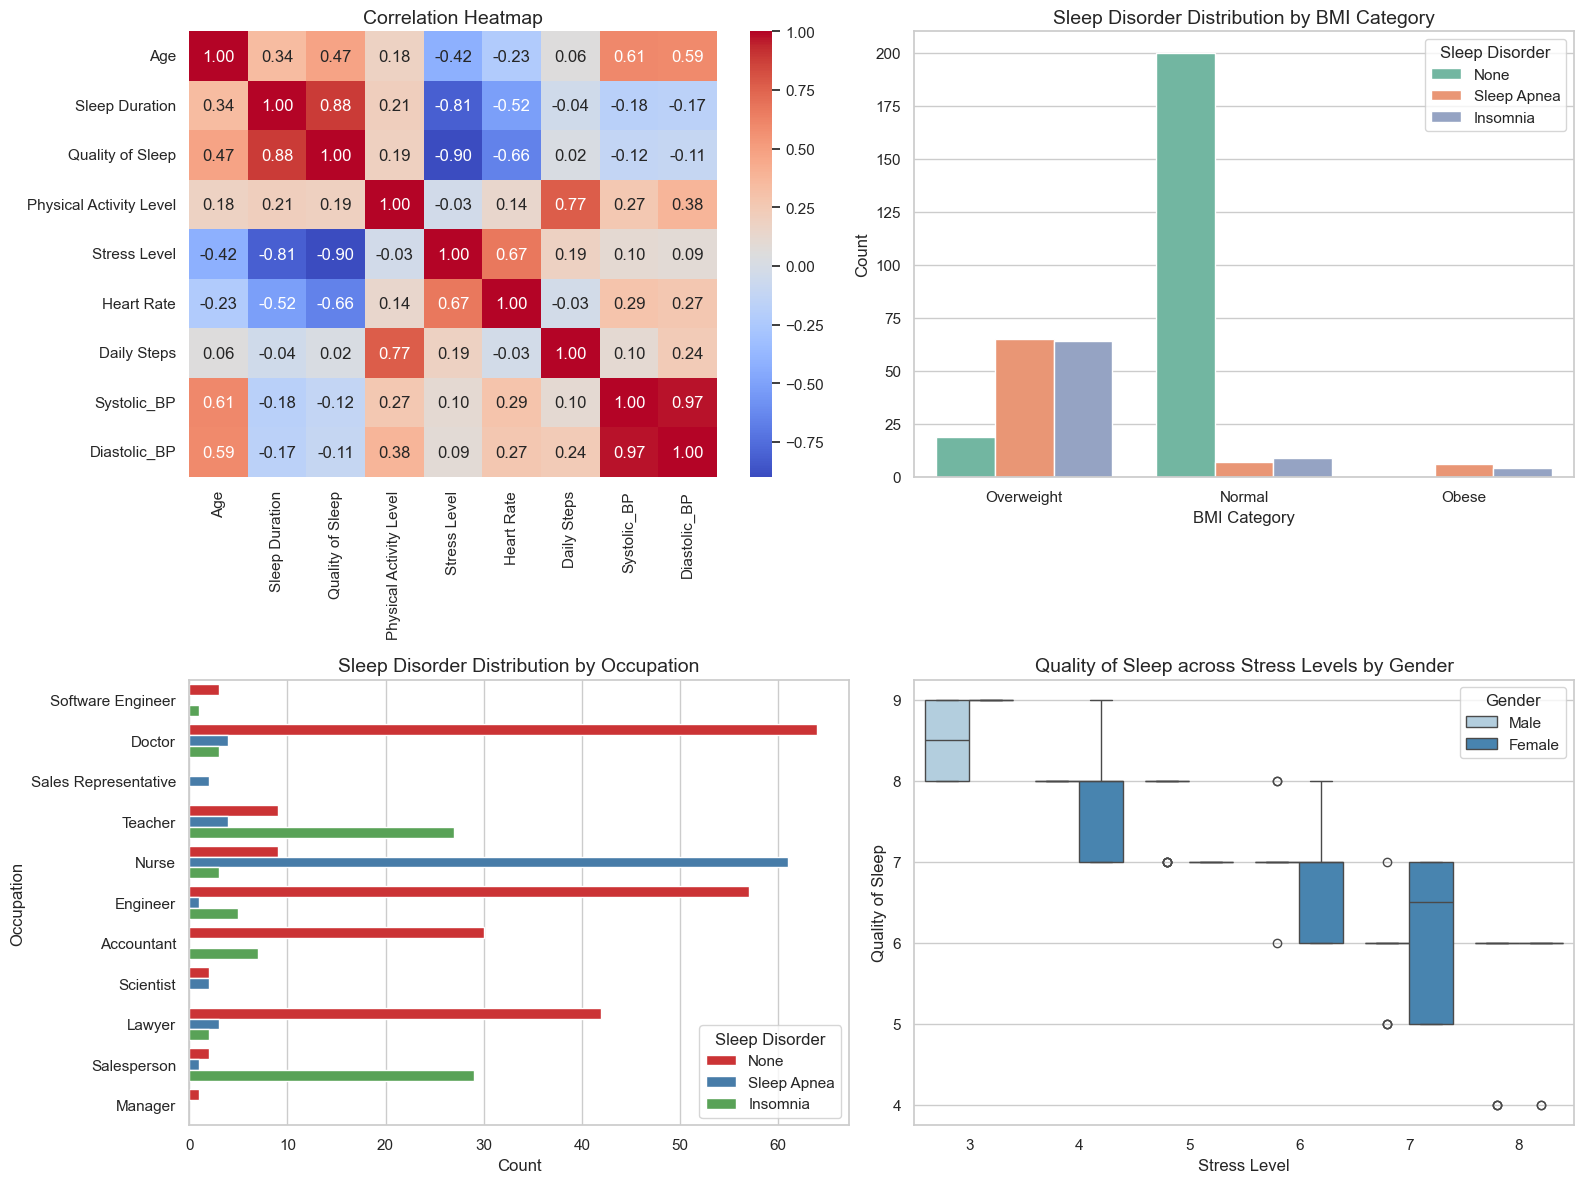

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Correlation Heatmap
num_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 
            'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP']
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0, 0])
axes[0, 0].set_title('Correlation Heatmap', fontsize=14)

# Plot 2: Sleep Disorder by BMI Category
sns.countplot(data=df_clean, x='BMI Category', hue='Sleep Disorder', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Sleep Disorder Distribution by BMI Category', fontsize=14)
axes[0, 1].set_ylabel('Count')

# Plot 3: Sleep Disorder by Occupation
sns.countplot(data=df_clean, y='Occupation', hue='Sleep Disorder', palette='Set1', ax=axes[1, 0])
axes[1, 0].set_title('Sleep Disorder Distribution by Occupation', fontsize=14)
axes[1, 0].set_xlabel('Count')

# Plot 4: Quality of Sleep across Stress Levels
sns.boxplot(data=df_clean, x='Stress Level', y='Quality of Sleep', hue='Gender', palette='Blues', ax=axes[1, 1])
axes[1, 1].set_title('Quality of Sleep across Stress Levels by Gender', fontsize=14)

plt.tight_layout()
plt.show()

In [7]:
# Grouped Summary Statistics by Sleep Disorder
disorder_metrics = df_clean.groupby('Sleep Disorder')[[
    'Sleep Duration', 
    'Quality of Sleep', 
    'Stress Level', 
    'Heart Rate', 
    'Systolic_BP', 
    'Diastolic_BP'
]].mean().round(2)

print("--- Average Vitals and Sleep Metrics by Category ---")
display(disorder_metrics)

--- Average Vitals and Sleep Metrics by Category ---


,Sleep Duration,Quality of Sleep,Stress Level,Heart Rate,Systolic_BP,Diastolic_BP
Sleep Disorder,,,,,,
Insomnia,6.59,6.53,5.87,70.47,132.04,86.86
None,7.36,7.63,5.11,69.02,124.05,81.00
Sleep Apnea,7.03,7.21,5.67,73.09,137.77,92.72


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Prepare feature matrix X and target y
X = df_clean.drop(columns=['Sleep Disorder'])
y = df_clean['Sleep Disorder']

# One-Hot Encode categorical features (Gender, Occupation, BMI Category)
X_encoded = pd.get_dummies(X, columns=['Gender', 'Occupation', 'BMI Category'], drop_first=True)

# Train-Test Split (80% Train, 20% Test) using Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize & Fit Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions & Performance
y_pred = rf_model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

Model Accuracy: 94.67%

--- Classification Report ---
              precision    recall  f1-score   support

    Insomnia       0.87      0.87      0.87        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.95        75
   macro avg       0.92      0.93      0.92        75
weighted avg       0.95      0.95      0.95        75



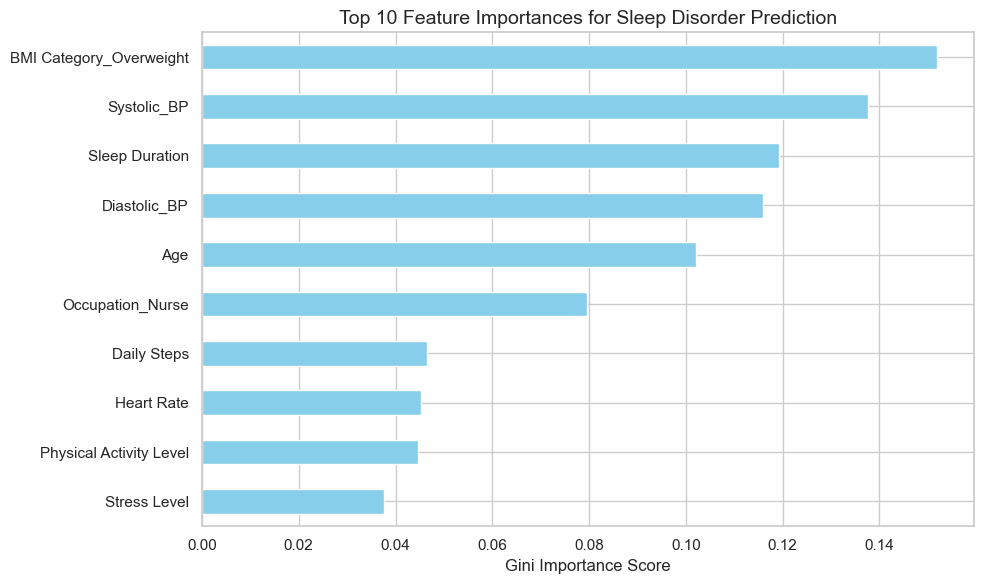

In [9]:
# Extract and plot top feature importances
importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='skyblue').invert_yaxis()
plt.title('Top 10 Feature Importances for Sleep Disorder Prediction', fontsize=14)
plt.xlabel('Gini Importance Score')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import GridSearchCV

# Define Hyperparameter Search Grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Run 5-Fold Stratified Cross-Validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Evaluate Best Model
best_rf = grid_search.best_estimator_
y_opt_pred = best_rf.predict(X_test)

print("Best Hyperparameters:", grid_search.best_params_)
print(f"Optimized Accuracy: {accuracy_score(y_test, y_opt_pred) * 100:.2f}%\n")
print("--- Optimized Classification Report ---")
print(classification_report(y_test, y_opt_pred))

Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Optimized Accuracy: 96.00%

--- Optimized Classification Report ---
              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.96        75
   macro avg       0.94      0.93      0.94        75
weighted avg       0.96      0.96      0.96        75

